## HW 2 is due on 02/15/2024 at 11:59 PM
## Instructions

1) Label your homework solutions with your ISU idnumber ( first 4 digits), such as HW1_Solutions_3938. This HW will be peer + Instructor graded.

2) Deliverables: You need to submit 3 files.
* ipython notebook file with all of your solutions and codes
* HTML file of your ipython notebook file.
* Your HW solution in a pdf file. Please write this part of the solution in a research paper format: Give a proper title, solve each problems and write findings so that you tell a story with the data set you have and the problems you need to solve. Attach plots, figures,  wherever necessary. 
 
3) Special instructions on how to solve the HW problems.
* For each problem, begin by solving it independently to the best of your ability. You can use ChatGPT, Google Bard, or other AI tools to seek hints, guidance, or alternative approaches to the problems. Engage these AI tools to enhance your understanding and explore different solution strategies.

* After completing all the problems, reflect on your experience by summarizing how you used ChatGPT/Bard or other AI tools, the specific problems you sought help with, and the valuable insights they offered. Discuss the strengths and limitations of both your initial solutions and the AI-generated ones for each of the problems. This integrated approach helps you leverage AI's power while refining your own analytical skills. It's not just about getting the answer; it's about learning through the process!

4) To submit your homework solutions, go to our course in Canvas --> Assignments --> HW 1 --> Submit Assignment --> Click "Choose File" --> choose the HTML file you saved --> Click another file--> choose ipynb file--> Repeat this process to add a pdf file--submit. Once you submit, download and check to ensure that you have submitted the correct files.

5) <font color='red'> WARNING: Your submission will be compared against other students' solutions and online databases to check for plagiarism. Disclosure of this assignment and assignment answers to anybody or any website is a contributory infringement of academic dishonesty at ISU. Do not share or post course materials without the express written consent of the copyright holder and instructor. The class will follow Iowa State University’s policy on academic dishonesty. Anyone suspected of academic dishonesty will be reported to the Dean of Students Office.</font>

#### Each problem is worth 20 points. Total $\bf 20\times 5 = 100$.

### Problem 1. 
In this problem, you will clean the data and perform exploratory data analysis (EDA) before proceeding with model development in subsequent tasks. For each part, explain the rationale behind your actions.

* The data contains duplications. Identify the cause of this issue and resolve it by eliminating the duplicates.
* Remove any column(s) that are not useful for regression or classification models.
* Identify and count missing values and address them by either removing or imputing them appropriately.
* Conduct EDA on the remaining columns. This may involve handling non-numerical values, changing data types, transforming or standardizing variables if necessary, and dummy coding certain variables.
* For classification purposes, create a column, using 'average rating' to create a new column called 'Rating' as below.
| averageRating | Rating |
| -------------| --------------------------- |
| >= 8      | *****        |
| >= 7      | ****     |
| >= 6     | ***     |
| >= 5      | **    |
| < 5      | *   |

In [1]:
import pandas as pd
import numpy as np

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [3]:
# Load the dataset
df = pd.read_csv('newimdb.csv')

In [4]:
df.head()

,Unnamed: 0,tconst,types,isOriginalTitle,titleType,originalTitle,isAdult,startYear,runtimeMinutes,genres,directors,category,averageRating,numVotes
0,6475881,tt0111596,imdbDisplay,0.0,movie,Vazir,0.0,2015,\N,"Action,Crime,Drama",nm13648797,editor,8.1,63.0
1,6475882,tt0111596,imdbDisplay,0.0,movie,Vazir,0.0,2015,\N,"Action,Crime,Drama",nm13648797,actor,8.1,63.0
2,6475884,tt0111596,imdbDisplay,0.0,movie,Vazir,0.0,2015,\N,"Action,Crime,Drama",nm13648797,actress,8.1,63.0
3,6475886,tt0111596,imdbDisplay,0.0,movie,Vazir,0.0,2015,\N,"Action,Crime,Drama",nm13648797,director,8.1,63.0
4,6475887,tt0111596,imdbDisplay,0.0,movie,Vazir,0.0,2015,\N,"Action,Crime,Drama",nm13648797,writer,8.1,63.0


In [5]:
df.tail()

,Unnamed: 0,tconst,types,isOriginalTitle,titleType,originalTitle,isAdult,startYear,runtimeMinutes,genres,directors,category,averageRating,numVotes
2795290,32998479,tt9916730,original,1.0,movie,6 Gunn,0.0,2017,116,\N,nm10538612,actor,8.1,9.0
2795291,32998483,tt9916730,original,1.0,movie,6 Gunn,0.0,2017,116,\N,nm10538612,director,8.1,9.0
2795292,32998484,tt9916730,original,1.0,movie,6 Gunn,0.0,2017,116,\N,nm10538612,producer,8.1,9.0
2795293,32998486,tt9916730,original,1.0,movie,6 Gunn,0.0,2017,116,\N,nm10538612,cinematographer,8.1,9.0
2795294,32998487,tt9916730,original,1.0,movie,6 Gunn,0.0,2017,116,\N,nm10538612,editor,8.1,9.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2795295 entries, 0 to 2795294
Data columns (total 14 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Unnamed: 0       int64  
 1   tconst           object 
 2   types            object 
 3   isOriginalTitle  float64
 4   titleType        object 
 5   originalTitle    object 
 6   isAdult          float64
 7   startYear        int64  
 8   runtimeMinutes   object 
 9   genres           object 
 10  directors        object 
 11  category         object 
 12  averageRating    float64
 13  numVotes         float64
dtypes: float64(4), int64(2), object(8)
memory usage: 298.6+ MB


In [7]:
df.shape

(2795295, 14)

In [8]:
df = df.drop_duplicates()
df.shape

(2795295, 14)

In [9]:
# Check for any duplicates
has_duplicates = df.duplicated().any()

In [10]:
print(has_duplicates)

False


In [11]:
# Check for any duplicate values in each column
for column in df.columns:
    has_duplicates = df[column].duplicated().any()

In [12]:
print(has_duplicates)

True


In [13]:
# Initialize a dictionary to hold the duplicate status for each column
duplicate_status = {}

# Check for any duplicate values in each column
for column in df.columns:
    duplicate_status[column] = df[column].duplicated().any()

# Print out duplicate status for each column
for column, has_duplicates in duplicate_status.items():
    print(f"Column '{column}' contains duplicated values: {has_duplicates}")

Column 'Unnamed: 0' contains duplicated values: False
Column 'tconst' contains duplicated values: True
Column 'types' contains duplicated values: True
Column 'isOriginalTitle' contains duplicated values: True
Column 'titleType' contains duplicated values: True
Column 'originalTitle' contains duplicated values: True
Column 'isAdult' contains duplicated values: True
Column 'startYear' contains duplicated values: True
Column 'runtimeMinutes' contains duplicated values: True
Column 'genres' contains duplicated values: True
Column 'directors' contains duplicated values: True
Column 'category' contains duplicated values: True
Column 'averageRating' contains duplicated values: True
Column 'numVotes' contains duplicated values: True


In [14]:
# Remove duplications based on a subset of columns that uniquely identify a movie
df = df.drop_duplicates(subset=['tconst', 'titleType', 'originalTitle', 'startYear'])

In [15]:
df.shape

(255860, 14)

In [16]:
#Remove Non-useful Columns
df.drop(['Unnamed: 0'], axis=1, inplace=True)


In [17]:
# Assuming 'df' is your DataFrame
# Convert '\N' to NaN across the entire DataFrame 'df'
df.replace('\\N', pd.NA, inplace=True)

In [18]:
missing_values = df.isnull().sum()
print(missing_values)

tconst                 0
types              38579
isOriginalTitle        0
titleType              0
originalTitle          0
isAdult                0
startYear              0
runtimeMinutes     44272
genres              2517
directors           9186
category               0
averageRating          0
numVotes               0
dtype: int64


In [19]:
# Replace '\N' with NaN in 'runtimeMinutes' and 'genres', then convert 'runtimeMinutes' to numeric
df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'].replace('\\N', np.nan), errors='coerce')
df['genres'] = df['genres'].replace('\\N', np.nan)

# Impute missing 'runtimeMinutes' with the median
df['runtimeMinutes'] = df['runtimeMinutes'].fillna(df['runtimeMinutes'].median())

# For 'genres', consider if imputation makes sense or if rows should be dropped/kept as is
# One approach is to fill missing genres with a placeholder like 'Unknown'
df['genres'] = df['genres'].fillna('Unknown')

In [20]:
df.head()

,tconst,types,isOriginalTitle,titleType,originalTitle,isAdult,startYear,runtimeMinutes,genres,directors,category,averageRating,numVotes
0,tt0111596,imdbDisplay,0.0,movie,Vazir,0.0,2015,75.0,"Action,Crime,Drama",nm13648797,editor,8.1,63.0
14,tt0118589,imdbDisplay,0.0,movie,Glitter,0.0,2001,104.0,"Drama,Music,Romance",nm0193554,cinematographer,2.4,23686.0
42,tt0118652,imdbDisplay,0.0,movie,The Attic Expeditions,0.0,2001,100.0,"Comedy,Horror,Mystery",nm0440948,composer,4.9,1850.0
66,tt0121164,imdbDisplay,0.0,movie,Corpse Bride,0.0,2005,77.0,"Animation,Drama,Family","nm0000318,nm0425843",writer,7.3,279860.0
86,tt0121389,imdbDisplay,0.0,short,"I, an Actress",0.0,2005,10.0,Short,nm0473647,actor,6.0,343.0


In [21]:
df.tail()

,tconst,types,isOriginalTitle,titleType,originalTitle,isAdult,startYear,runtimeMinutes,genres,directors,category,averageRating,numVotes
2795221,tt9916270,imdbDisplay,0.0,movie,Il talento del calabrone,0.0,2020,84.0,Thriller,nm1480867,cinematographer,5.8,1393.0
2795249,tt9916362,imdbDisplay,0.0,movie,Akelarre,0.0,2020,92.0,"Drama,History",nm1893148,composer,6.4,5179.0
2795267,tt9916460,imdbDisplay,0.0,tvMovie,Pink Taxi,0.0,2019,75.0,Comedy,nm7048843,actor,9.4,18.0
2795279,tt9916538,<NA>,0.0,movie,Kuambil Lagi Hatiku,0.0,2019,123.0,Drama,nm4457074,composer,8.3,6.0
2795285,tt9916730,imdbDisplay,0.0,movie,6 Gunn,0.0,2017,116.0,Unknown,nm10538612,actor,8.1,9.0


In [22]:
from sklearn.preprocessing import StandardScaler

# Conducting EDA: Transforming or standardizing variables
# For simplicity, let's standardize 'runtimeMinutes', 'averageRating', and 'numVotes'
scaler = StandardScaler()
df[['runtimeMinutes', 'averageRating', 'numVotes']] = scaler.fit_transform(df[['runtimeMinutes', 'averageRating', 'numVotes']])

# Dummy coding categorical variables
# Encoding 'titleType' and 'category'; 'genres' will be handled differently due to multiple categories per movie
df = pd.get_dummies(df, columns=['titleType', 'category'], drop_first=True)

# Handling 'genres': One-hot encoding where each genre gets its column
genres_expanded = df['genres'].str.get_dummies(sep=',')
df = pd.concat([df, genres_expanded], axis=1).drop('genres', axis=1)
df.head()

,tconst,types,isOriginalTitle,originalTitle,isAdult,startYear,runtimeMinutes,directors,averageRating,numVotes,...,Reality-TV,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,Unknown,War,Western
0,tt0111596,imdbDisplay,0.0,Vazir,0.0,2015,0.036569,nm13648797,0.950009,-0.092001,...,0,0,0,0,0,0,0,0,0,0
14,tt0118589,imdbDisplay,0.0,Glitter,0.0,2001,0.214138,nm0193554,-2.804575,0.732189,...,0,1,0,0,0,0,0,0,0,0
42,tt0118652,imdbDisplay,0.0,The Attic Expeditions,0.0,2001,0.189645,nm0440948,-1.157827,-0.029654,...,0,0,0,0,0,0,0,0,0,0
66,tt0121164,imdbDisplay,0.0,Corpse Bride,0.0,2005,0.048815,"nm0000318,nm0425843",0.423050,9.669925,...,0,0,0,0,0,0,0,0,0,0
86,tt0121389,imdbDisplay,0.0,"I, an Actress",0.0,2005,-0.361430,nm0473647,-0.433259,-0.082232,...,0,0,0,1,0,0,0,0,0,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 255860 entries, 0 to 2795285
Data columns (total 58 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   tconst                        255860 non-null  object 
 1   types                         217281 non-null  object 
 2   isOriginalTitle               255860 non-null  float64
 3   originalTitle                 255860 non-null  object 
 4   isAdult                       255860 non-null  float64
 5   startYear                     255860 non-null  int64  
 6   runtimeMinutes                255860 non-null  float64
 7   directors                     246674 non-null  object 
 8   averageRating                 255860 non-null  float64
 9   numVotes                      255860 non-null  float64
 10  titleType_short               255860 non-null  bool   
 11  titleType_tvEpisode           255860 non-null  bool   
 12  titleType_tvMiniSeries        255860 non-null  b

In [24]:
# Creating a 'Rating' column for classification based on 'averageRating'
def map_rating(averageRating):
    if averageRating >= 8:
        return '*****'
    elif averageRating >= 7:
        return '****'
    elif averageRating >= 6:
        return '***'
    elif averageRating >= 5:
        return '**'
    else:
        return '*'

# Apply the function to the standardized 'averageRating' column. Note: if 'averageRating' was standardized, adjust this logic as needed.
df['Rating'] = df['averageRating'].apply(lambda x: x * scaler.scale_[1] + scaler.mean_[1]).apply(map_rating)

# Show the first few rows to verify changes
df.head()

,tconst,types,isOriginalTitle,originalTitle,isAdult,startYear,runtimeMinutes,directors,averageRating,numVotes,...,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,Unknown,War,Western,Rating
0,tt0111596,imdbDisplay,0.0,Vazir,0.0,2015,0.036569,nm13648797,0.950009,-0.092001,...,0,0,0,0,0,0,0,0,0,*****
14,tt0118589,imdbDisplay,0.0,Glitter,0.0,2001,0.214138,nm0193554,-2.804575,0.732189,...,1,0,0,0,0,0,0,0,0,*
42,tt0118652,imdbDisplay,0.0,The Attic Expeditions,0.0,2001,0.189645,nm0440948,-1.157827,-0.029654,...,0,0,0,0,0,0,0,0,0,*
66,tt0121164,imdbDisplay,0.0,Corpse Bride,0.0,2005,0.048815,"nm0000318,nm0425843",0.423050,9.669925,...,0,0,0,0,0,0,0,0,0,****
86,tt0121389,imdbDisplay,0.0,"I, an Actress",0.0,2005,-0.361430,nm0473647,-0.433259,-0.082232,...,0,0,1,0,0,0,0,0,0,***


In [25]:
df.tail()

,tconst,types,isOriginalTitle,originalTitle,isAdult,startYear,runtimeMinutes,directors,averageRating,numVotes,...,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,Unknown,War,Western,Rating
2795221,tt9916270,imdbDisplay,0.0,Il talento del calabrone,0.0,2020,0.091676,nm1480867,-0.564998,-0.045598,...,0,0,0,0,0,1,0,0,0,**
2795249,tt9916362,imdbDisplay,0.0,Akelarre,0.0,2020,0.140661,nm1893148,-0.169779,0.086493,...,0,0,0,0,0,0,0,0,0,***
2795267,tt9916460,imdbDisplay,0.0,Pink Taxi,0.0,2019,0.036569,nm7048843,1.806318,-0.093571,...,0,0,0,0,0,0,0,0,0,*****
2795279,tt9916538,<NA>,0.0,Kuambil Lagi Hatiku,0.0,2019,0.330476,nm4457074,1.081749,-0.093990,...,0,0,0,0,0,0,0,0,0,*****
2795285,tt9916730,imdbDisplay,0.0,6 Gunn,0.0,2017,0.287614,nm10538612,0.950009,-0.093885,...,0,0,0,0,0,0,1,0,0,*****


### Problem 2.  
You will make regression models here using the cleaned data from problem 1. Use averageRating as the target variable for this problem.
* Make 5 Multiple Linear/Nonlinear Regression models using machine learning models that are beyond the basics (regular linear regression, also called OLS, Decision Tree, Random Forest, K - Nearest Neighbours, and SVM).
* Pick your test size and validation method and size and explain your resons on why.
* Then make a data frame of predictions for the test data using each model and show the head of the data frame.
* Make tables showing RMSE and R-squared for all five models for training and testing data. Which model do you pick among these 5, and explain why? 
* Is your best model good enough to be used for production? Why or why not? What will you do to improve the model?

In [26]:
#Data Preparations

# Exclude the 'Rating' column and any other non-numeric columns from the features set
X = df.drop(['tconst', 'types', 'originalTitle', 'directors', 'averageRating', 'Rating'], axis=1, errors='ignore')


# Target variable
y = df['averageRating']

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [27]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler to the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data
X_test_scaled = scaler.transform(X_test)


In [28]:
# Lasso Regression
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)


LassoCV(cv=5, random_state=42)

In [29]:
#Ridge Regression
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=[1e-3, 1e-2, 1e-1, 1])
ridge.fit(X_train_scaled, y_train)


RidgeCV(alphas=[0.001, 0.01, 0.1, 1])

In [30]:
#Elastic Net Regression
from sklearn.linear_model import ElasticNetCV

elastic_net = ElasticNetCV(cv=5, random_state=42)
elastic_net.fit(X_train_scaled, y_train)

ElasticNetCV(cv=5, random_state=42)

In [31]:
# Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

gb_reg = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_reg.fit(X_train, y_train)


GradientBoostingRegressor(random_state=42)

In [32]:
!pip install xgboost

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/24/ec/ad387100fa3cc2b9b81af0829b5ecfe75ec5bb19dd7c19d4fea06fb81802/xgboost-2.0.3-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/99.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/99.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/99.8 MB ? eta -:--:--
   ---------------------------------------- 0.1/99.8 MB 550.5 kB/s eta 0:03:02
   ---------------------------------------- 0.1/99.8 MB 585.1 kB/s eta 0:02:51
   ---------------------------------------- 0.1/99.8 MB 658.7 kB/s eta 0:02:32
   ---------------------------------------- 0.2/99.8 MB 798.5 kB/s eta 0:02:05
   ---------------------------------------- 0.3/99.8 MB 874.6 kB/s eta 0:01:54
   ---------------------------------------- 0.4/99.8 MB 1.0 MB/s eta 0:01:36
   ---------------------------------------- 0.4/99.8 MB 971.5 kB/s eta 0:01:43
   -------------------------------

In [33]:
#XGBoost Regressor
import xgboost as xgb

xgb_reg = xgb.XGBRegressor(objective ='reg:squarederror', colsample_bytree=0.3, learning_rate=0.1,
                max_depth=5, alpha=10, n_estimators=100, random_state=42)
xgb_reg.fit(X_train, y_train)


XGBRegressor(alpha=10, base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.3, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, ...)

In [34]:
# "X_test" wasn't appropriately scaled for Lasso,Ridge and ElasticNet predictions.
#That why I am using X_test_scaled

predictions = {
    "Lasso": lasso.predict(X_test_scaled),
    "Ridge":ridge.predict(X_test_scaled),
    "Elastic": elastic_net.predict(X_test_scaled),
    "GB": gb_reg.predict(X_test),
    "XGB": xgb_reg.predict(X_test),
}

predictions_df = pd.DataFrame(predictions)
predictions_df.head()

,Lasso,Ridge,Elastic,GB,XGB
0,0.006983,0.006857,0.006992,-0.019774,0.085402
1,-0.560524,-0.561442,-0.560245,-0.967412,-1.056091
2,-0.303878,-0.303486,-0.303855,-0.215345,-0.291311
3,-0.363507,-0.368037,-0.363362,0.139804,-0.092048
4,0.269083,0.268196,0.269120,0.437192,0.422925


In [35]:
#Evaluate each model using RMSE and R-squared on both the training and test datasets.
from sklearn.metrics import mean_squared_error, r2_score

models = [lasso, ridge, elastic_net, gb_reg, xgb_reg]
model_names = ['Lasso', 'Ridge', 'Elastic Net', 'Gradient Boosting', 'XGBoost']

for model, name in zip(models, model_names):
    y_pred_train = model.predict(X_train_scaled if name in ['Lasso', 'Ridge', 'Elastic Net'] else X_train)
    y_pred_test = model.predict(X_test_scaled if name in ['Lasso', 'Ridge', 'Elastic Net'] else X_test)
    rmse_train = mean_squared_error(y_train, y_pred_train, squared=False)
    r2_train = r2_score(y_train, y_pred_train)
    rmse_test = mean_squared_error(y_test, y_pred_test, squared=False)
    r2_test = r2_score(y_test, y_pred_test)
    
    print(f"{name} Training - RMSE: {rmse_train:.2f}, R-squared: {r2_train:.2f}")
    print(f"{name} Testing - RMSE: {rmse_test:.2f}, R-squared: {r2_test:.2f}\n")


Lasso Training - RMSE: 0.90, R-squared: 0.19
Lasso Testing - RMSE: 0.91, R-squared: 0.19

Ridge Training - RMSE: 0.90, R-squared: 0.19
Ridge Testing - RMSE: 0.91, R-squared: 0.19

Elastic Net Training - RMSE: 0.90, R-squared: 0.19
Elastic Net Testing - RMSE: 0.91, R-squared: 0.19

Gradient Boosting Training - RMSE: 0.86, R-squared: 0.27
Gradient Boosting Testing - RMSE: 0.86, R-squared: 0.26

XGBoost Training - RMSE: 0.85, R-squared: 0.28
XGBoost Testing - RMSE: 0.86, R-squared: 0.27



### Problem 3.  
You will make classification models here. Use Rating as the target variable. Make sure to exclude averageRating(Why?) from the predictor variables.

* Make 5 classification models using machine learning models that are beyond the basics (Multinomial Logistic Regression, Decision Tree, Random Forest, K - Nearest Neighbours, and SVM). 
* Pick your test size and validation method and size and explain your resons on why.
* Make a table with all the 5 model's accuracy score for the test and the train data and plot the colored heatmap for the test data of your best model?
*  What one other metric do you want to use for validating your model? Which model performs best based on this metric?
* Is your best model good enough to be used for production? Why or why not? What will you do to improve the model?

In [36]:
from sklearn.preprocessing import LabelEncoder

# Drop non-numeric columns
# Assuming 'tconst', 'types', 'originalTitle', 'directors' are non-numeric object columns
X = df.drop(['Rating', 'averageRating', 'tconst', 'types', 'originalTitle', 'directors'], axis=1)

# Convert booleans to integers (if any boolean columns are in the dataset)
X = X*1  # This will convert True/False to 1/0

# Encode the 'Rating' target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['Rating'])

# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(X, y_encoded, test_size=0.2, random_state=42)


In [37]:
#Linear Discriminant Analysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train_encoded)

LinearDiscriminantAnalysis()

In [38]:
#Naive Bayes Classifier
from sklearn.naive_bayes import GaussianNB

naive_bayes = GaussianNB()
naive_bayes.fit(X_train, y_train_encoded)

GaussianNB()

In [39]:
#Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

gbc_model = GradientBoostingClassifier(random_state=42)
gbc_model.fit(X_train, y_train_encoded)

GradientBoostingClassifier(random_state=42)

In [40]:
#AdaBoost Classifier
from sklearn.ensemble import AdaBoostClassifier

adaboost_model = AdaBoostClassifier(random_state=42)
adaboost_model.fit(X_train, y_train_encoded)


AdaBoostClassifier(random_state=42)

In [41]:
#Extra Trees Classifier
from sklearn.ensemble import ExtraTreesClassifier

etc_model = ExtraTreesClassifier(random_state=42)
etc_model.fit(X_train, y_train_encoded)

ExtraTreesClassifier(random_state=42)

In [42]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the models
models = {
    'Linear Discriminant Analysis': LinearDiscriminantAnalysis(),
    'Naive Bayes Classifier': GaussianNB(),
    'Gradient Boosting Classifier': GradientBoostingClassifier(random_state=42),
    'AdaBoost Classifier': AdaBoostClassifier(random_state=42),
    'Extra Trees Classifier': ExtraTreesClassifier(random_state=42)
}

# Train and evaluate each model
model_results = {}
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train_encoded)
    
    # Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Evaluate the model
    train_accuracy = accuracy_score(y_train_encoded, y_pred_train)
    test_accuracy = accuracy_score(y_test_encoded, y_pred_test)
    conf_matrix = confusion_matrix(y_test_encoded, y_pred_test)
    classif_report = classification_report(y_test_encoded, y_pred_test)
    
    # Store results in a dictionary
    model_results[name] = {
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'Confusion Matrix': conf_matrix,
        'Classification Report': classif_report
    }

# Display the results
for name, results in model_results.items():
    print(f"Model: {name}")
    print(f"Train Accuracy: {results['Train Accuracy']:.2f}")
    print(f"Test Accuracy: {results['Test Accuracy']:.2f}")
    print("Confusion Matrix:")
    print(results['Confusion Matrix'])
    print("Classification Report:")
    print(results['Classification Report'])
    print("\n")


Model: Linear Discriminant Analysis
Train Accuracy: 0.35
Test Accuracy: 0.36
Confusion Matrix:
[[2295  477 2325  876  656]
 [1235  636 3463 1393 1006]
 [1081  503 5545 3796 2228]
 [ 734  176 3582 6051 2813]
 [ 506  123 1972 3968 3732]]
Classification Report:
              precision    recall  f1-score   support

           0       0.39      0.35      0.37      6629
           1       0.33      0.08      0.13      7733
           2       0.33      0.42      0.37     13153
           3       0.38      0.45      0.41     13356
           4       0.36      0.36      0.36     10301

    accuracy                           0.36     51172
   macro avg       0.36      0.33      0.33     51172
weighted avg       0.36      0.36      0.34     51172



Model: Naive Bayes Classifier
Train Accuracy: 0.23
Test Accuracy: 0.23
Confusion Matrix:
[[5505  192  145  265  522]
 [5605  417  386  460  865]
 [7839  766 1093 1300 2155]
 [6651  516 1282 1746 3161]
 [5303  305  589 1050 3054]]
Classification Repor

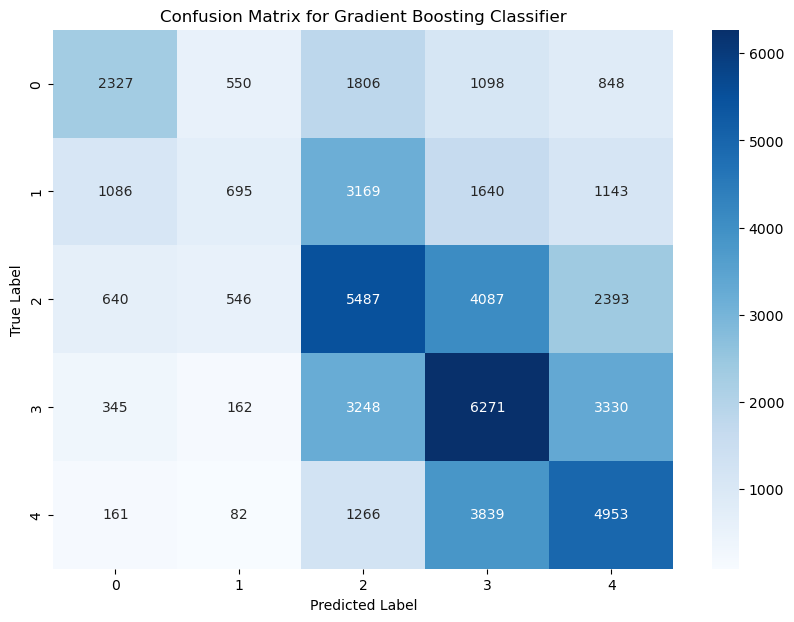

In [43]:
# Determine the best model based on Test Accuracy 
best_model_name = max(model_results, key=lambda x: model_results[x]['Test Accuracy'])
best_model = models[best_model_name]

# Compute confusion matrix for the best model
cm = confusion_matrix(y_test_encoded, best_model.predict(X_test))

# Plot the heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


### Problem 4. 
For this problem, you'll create clustering models using techniques other than K-Means clustering.

* Select relevant columns from the cleaned data for clustering. Briefly explain your choices and determine the appropriate number of clusters (K) you want to use and justify your reasoning.
* Implement three clustering models with the chosen features and predict cluster assignments for data points.
* Explore methods to compare the generated models. Discuss suitable metrics and compare their performance. Select the preferred model based on the chosen metric and justify your choice.
* Explain how you'll utilize the chosen clustering model to gain insights from the data.
* Based on your analysis, extract up to three key insights gleaned from using clustering techniques. Briefly describe how you arrived at these insights.


In [44]:
df.columns

Index(['tconst', 'types', 'isOriginalTitle', 'originalTitle', 'isAdult',
       'startYear', 'runtimeMinutes', 'directors', 'averageRating', 'numVotes',
       'titleType_short', 'titleType_tvEpisode', 'titleType_tvMiniSeries',
       'titleType_tvMovie', 'titleType_tvSeries', 'titleType_tvShort',
       'titleType_tvSpecial', 'titleType_video', 'titleType_videoGame',
       'category_actress', 'category_archive_footage',
       'category_archive_sound', 'category_cinematographer',
       'category_composer', 'category_director', 'category_editor',
       'category_producer', 'category_production_designer', 'category_self',
       'category_writer', 'Action', 'Adult', 'Adventure', 'Animation',
       'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family',
       'Fantasy', 'Game-Show', 'History', 'Horror', 'Music', 'Musical',
       'Mystery', 'News', 'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport',
       'Talk-Show', 'Thriller', 'Unknown', 'War', 'Western', 'Rating'],
 

For n_clusters = 2, the average silhouette_score is : 0.793598902835047
For n_clusters = 3, the average silhouette_score is : 0.7965740401450213
For n_clusters = 4, the average silhouette_score is : 0.2331057713423223
For n_clusters = 5, the average silhouette_score is : 0.23934177749671834
For n_clusters = 6, the average silhouette_score is : 0.23757888705473656
For n_clusters = 7, the average silhouette_score is : 0.20820238917130773
For n_clusters = 8, the average silhouette_score is : 0.2098506334471852
For n_clusters = 9, the average silhouette_score is : 0.2120772017271459


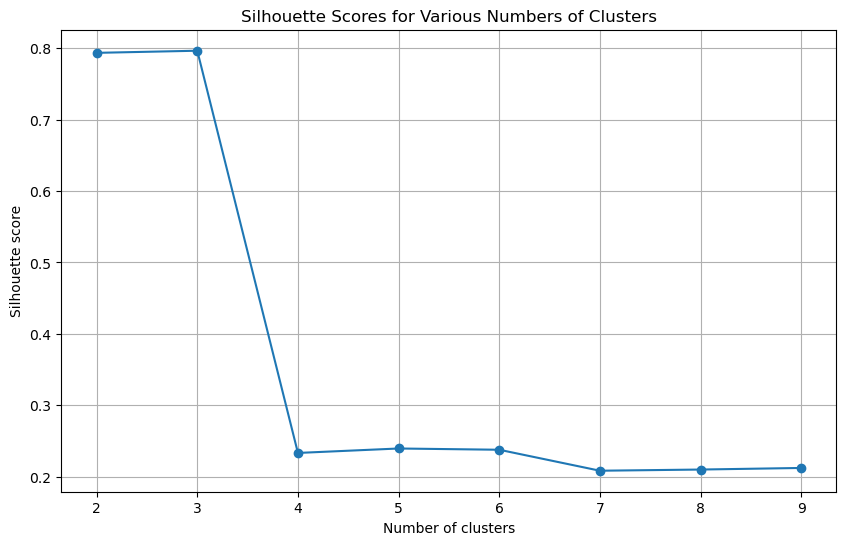

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Sample a subset of the data for efficient computation
# Adjust `sample_size` as necessary to fit your computational capacity
sample_size = 10000  # Example sample size
df_sample = df.sample(n=sample_size, random_state=42)

# Select and preprocess features
features = ['isAdult', 'averageRating', 'numVotes', 'startYear', 'runtimeMinutes']
X = df_sample[features].fillna(0)  # Handling missing values
X_scaled = StandardScaler().fit_transform(X)  # Standardizing the features

# Range of clusters to try
cluster_range = range(2, 10)

# Placeholder for silhouette scores
silhouette_scores = []

for n_clusters in cluster_range:
    clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    cluster_labels = clusterer.fit_predict(X_scaled)
    
    # Calculate the silhouette score and append it to the list
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg}")

# Plotting the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, silhouette_scores, marker='o')
plt.title('Silhouette Scores for Various Numbers of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()


In [46]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN, SpectralClustering

# Assuming 'X_scaled' is the standardized features from your dataset

# 1. Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=3)  # We choose 3 based on silhouette scores
agg_clusters = agg_clustering.fit_predict(X_scaled)
df_sample['Agg_Cluster'] = agg_clusters  # Add the cluster assignments to the DataFrame


In [47]:
# 2. DBSCAN
# The parameters for DBSCAN need to be chosen based on the dataset. The default values are eps=0.5 and min_samples=5.
# These may need to be adjusted after evaluating the results.
dbscan_clustering = DBSCAN(eps=0.5, min_samples=5)
dbscan_clusters = dbscan_clustering.fit_predict(X_scaled)
df_sample['DBSCAN_Cluster'] = dbscan_clusters  # Add the cluster assignments to the DataFrame


In [48]:
# 3. Spectral Clustering
# Number of clusters is set to 3 based on silhouette scores.
spectral_clustering = SpectralClustering(n_clusters=3, affinity='nearest_neighbors')
spectral_clusters = spectral_clustering.fit_predict(X_scaled)
df_sample['Spectral_Cluster'] = spectral_clusters  # Add the cluster assignments to the DataFrame

C:\Users\aksingh2\AppData\Local\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [49]:
# The DataFrame now contains the cluster assignments from all three methods
df_sample[['Agg_Cluster', 'DBSCAN_Cluster', 'Spectral_Cluster']].head()

,Agg_Cluster,DBSCAN_Cluster,Spectral_Cluster
1219699,0,0,0
647808,0,0,0
101434,0,0,0
590649,0,0,0
2689569,0,0,1


In [50]:
df_sample['Agg_Cluster'].unique()

array([0, 2, 1], dtype=int64)

In [57]:
df_sample['DBSCAN_Cluster'].unique()

array([ 0, -1,  1,  2,  3], dtype=int64)

In [52]:
df_sample['Spectral_Cluster'].unique()

array([0, 1, 2])

In [53]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# For Agglomerative Clustering
agg_silhouette = silhouette_score(X_scaled, df_sample['Agg_Cluster'])
agg_davies = davies_bouldin_score(X_scaled, df_sample['Agg_Cluster'])
agg_calinski = calinski_harabasz_score(X_scaled, df_sample['Agg_Cluster'])

# For DBSCAN
# We will only include non-noise points (-1 label) in our evaluation for DBSCAN
dbscan_mask = df_sample['DBSCAN_Cluster'] != -1
dbscan_silhouette = silhouette_score(X_scaled[dbscan_mask], df_sample[dbscan_mask]['DBSCAN_Cluster'])
dbscan_davies = davies_bouldin_score(X_scaled[dbscan_mask], df_sample[dbscan_mask]['DBSCAN_Cluster'])
dbscan_calinski = calinski_harabasz_score(X_scaled[dbscan_mask], df_sample[dbscan_mask]['DBSCAN_Cluster'])

# For Spectral Clustering
spec_silhouette = silhouette_score(X_scaled, df_sample['Spectral_Cluster'])
spec_davies = davies_bouldin_score(X_scaled, df_sample['Spectral_Cluster'])
spec_calinski = calinski_harabasz_score(X_scaled, df_sample['Spectral_Cluster'])

print("Agglomerative Clustering Metrics:\n",
      f"Silhouette: {agg_silhouette}\n Davies-Bouldin: {agg_davies}\n Calinski-Harabasz: {agg_calinski}\n")

print("DBSCAN Metrics:\n",
      f"Silhouette: {dbscan_silhouette}\n Davies-Bouldin: {dbscan_davies}\n Calinski-Harabasz: {dbscan_calinski}\n")

print("Spectral Clustering Metrics:\n",
      f"Silhouette: {spec_silhouette}\n Davies-Bouldin: {spec_davies}\n Calinski-Harabasz: {spec_calinski}")


Agglomerative Clustering Metrics:
 Silhouette: 0.7965740401450213
 Davies-Bouldin: 0.43070898126324036
 Calinski-Harabasz: 2500.579298306003

DBSCAN Metrics:
 Silhouette: 0.24213080151007207
 Davies-Bouldin: 0.9358000955439426
 Calinski-Harabasz: 550.824821376993

Spectral Clustering Metrics:
 Silhouette: 0.24772419389618716
 Davies-Bouldin: 1.164819546446624
 Calinski-Harabasz: 2587.865707356368


### Problem 5. 
Upload the AirPassenger data. The dataset has two columns: Month representing the time in a specific format (e.g., "1949-01" for January 1949) and #Passengers representing the number of passengers for each corresponding month.

* Do the Exploratory Data Analysis (EDA) on the data. This involves using date time to extract month and year, showing summary statistics, visualizing the overall distribution of passenger counts, visually inspecting the trend, seasonality, and any apparent patterns, and decomposing the time series into its components (trend, seasonality, residual) and visualize each component.
* Apply ARIMA, Exponential Smoothing, and Prophet. Evaluate the accuracy of all three forecasting methods using appropriate metrics.
* Use autocorrelation and partial autocorrelation plots to identify lag relationships in the time series data.
* Implement a technique such as moving averages or differencing to remove trends and make patterns more apparent.

* Implement an anomaly detection method, such as a rolling average with anomaly thresholds, and Visualize and analyze the identified anomalies in the context of the time series.


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error
from math import sqrt

In [58]:
ap=pd.read_csv('AirPassengers.csv')

In [59]:
ap.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [60]:
ap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [61]:
ap['Month'] = pd.to_datetime(ap['Month'])

In [62]:
ap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [63]:
ap['Month'] = pd.to_datetime(ap['Month'])

# EDA
ap['Year'] = ap['Month'].dt.year
ap['Month_Num'] = ap['Month'].dt.month

ap.head()

,Month,#Passengers,Year,Month_Num
0,1949-01-01,112,1949,1
1,1949-02-01,118,1949,2
2,1949-03-01,132,1949,3
3,1949-04-01,129,1949,4
4,1949-05-01,121,1949,5


In [64]:
# Show summary statistics
print(ap.describe())

                     Month  #Passengers         Year   Month_Num
count                  144   144.000000   144.000000  144.000000
mean   1954-12-16 05:00:00   280.298611  1954.500000    6.500000
min    1949-01-01 00:00:00   104.000000  1949.000000    1.000000
25%    1951-12-24 06:00:00   180.000000  1951.750000    3.750000
50%    1954-12-16 12:00:00   265.500000  1954.500000    6.500000
75%    1957-12-08 18:00:00   360.500000  1957.250000    9.250000
max    1960-12-01 00:00:00   622.000000  1960.000000   12.000000
std                    NaN   119.966317     3.464102    3.464102


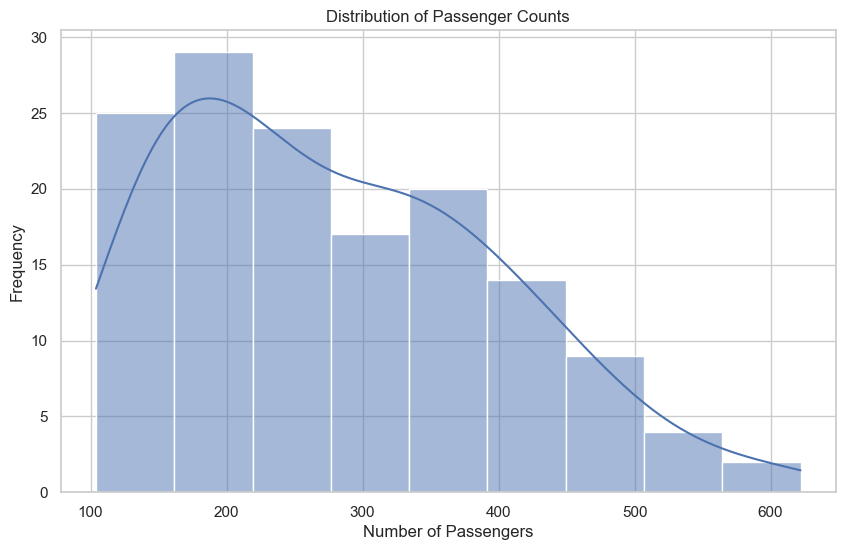

In [65]:
# Distribution of passenger counts
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(ap['#Passengers'], kde=True)
plt.title('Distribution of Passenger Counts')
plt.xlabel('Number of Passengers')
plt.ylabel('Frequency')
plt.show()

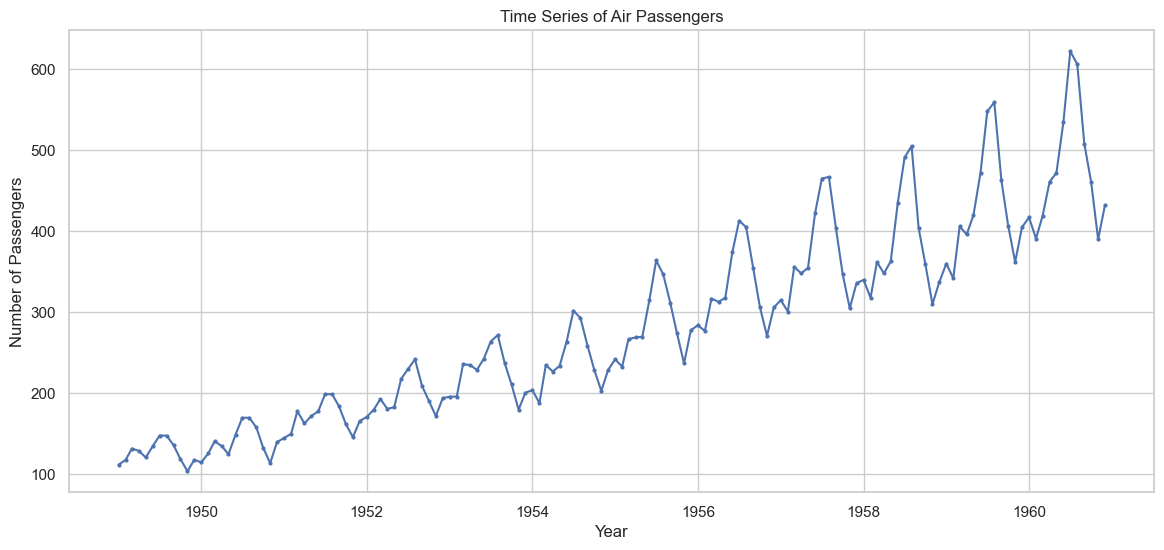

In [66]:
# Time Series Plot
plt.figure(figsize=(14, 6))
plt.plot(ap['Month'], ap['#Passengers'], marker='o', linestyle='-', markersize=2)
plt.title('Time Series of Air Passengers')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.show()

In [67]:
# Decomposing the time series
decomposed = seasonal_decompose(ap.set_index('Month')['#Passengers'], model='multiplicative')

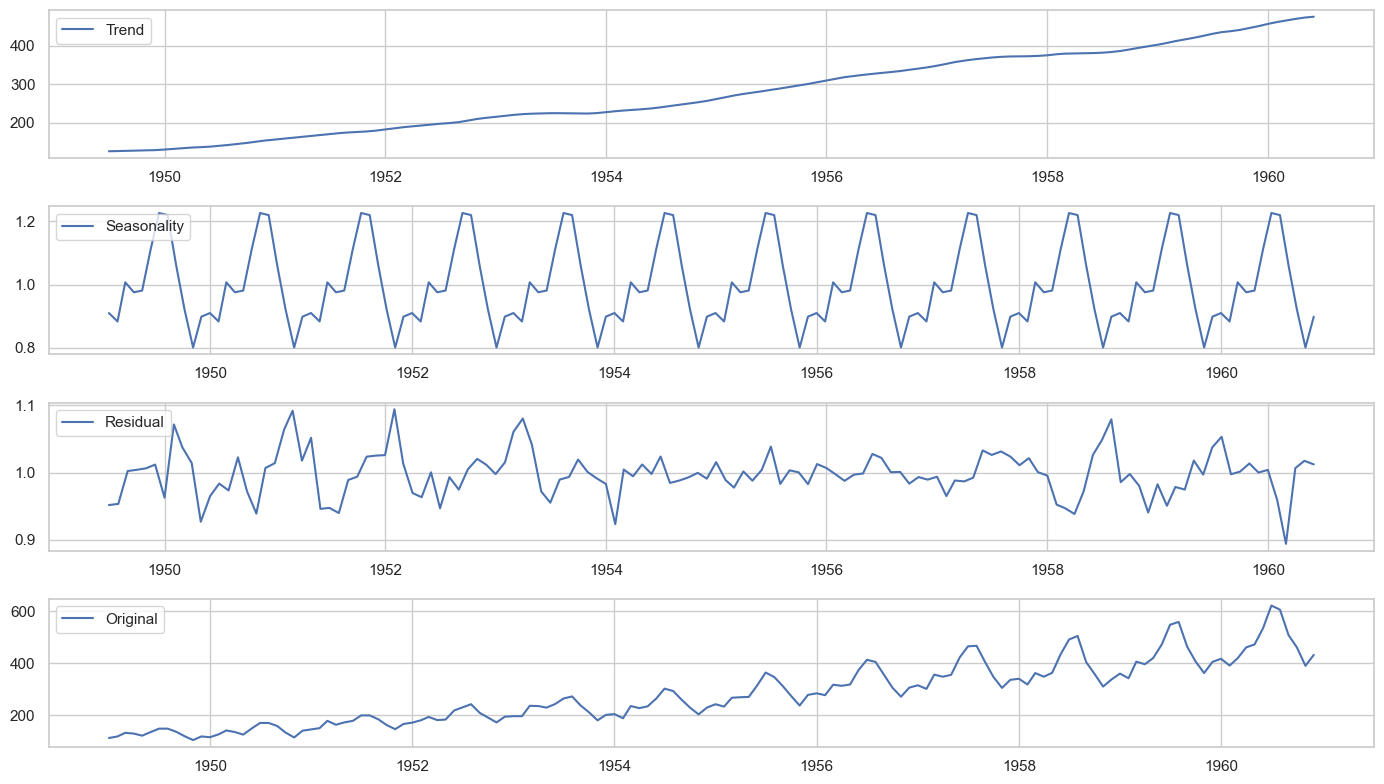

In [68]:
# Plotting the decomposed components
plt.figure(figsize=(14, 8))

plt.subplot(411)
plt.plot(decomposed.trend, label='Trend')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(decomposed.seasonal,label='Seasonality')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(decomposed.resid, label='Residual')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(ap['Month'], ap['#Passengers'], label='Original')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [69]:
# Prepare the time series data
time_series = ap.set_index('Month')['#Passengers']

# Split the data into train and test sets
train = time_series[:-12]  # Exclude the last 12 months for testing
test = time_series[-12:]

# ARIMA Model
arima_model = ARIMA(train, order=(5,1,0))  # Example order, adjust based on ACF/PACF analysis
arima_result = arima_model.fit()
arima_forecast = arima_result.forecast(steps=12)
rmse_arima = sqrt(mean_squared_error(test, arima_forecast))
print(f'ARIMA RMSE: {rmse_arima}')

# Exponential Smoothing Model
es_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12)
es_result = es_model.fit()
es_forecast = es_result.forecast(steps=12)
rmse_es = sqrt(mean_squared_error(test, es_forecast))
print(f'Exponential Smoothing RMSE: {rmse_es}')


C:\Users\aksingh2\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\aksingh2\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\aksingh2\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\aksingh2\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


ARIMA RMSE: 86.81013007491157
Exponential Smoothing RMSE: 16.979663509487658


In [70]:
!pip install prophet

  Obtaining dependency information for prophet from https://files.pythonhosted.org/packages/24/2b/834e9a347f2f0161e32a3c6125b8a1ebdf6ac33199a0ed3a0bdf1f0c296f/prophet-1.1.5-py3-none-win_amd64.whl.metadata
  Obtaining dependency information for cmdstanpy>=1.0.4 from https://files.pythonhosted.org/packages/5b/a0/a0f4a556dff2189bc08d0f69f0d4aac1b7e4e0cedc9a70b30a134f73d100/cmdstanpy-1.2.1-py3-none-any.whl.metadata
  Obtaining dependency information for holidays>=0.25 from https://files.pythonhosted.org/packages/e2/42/04d07feeb46fa0d260aa5d9431311d31517b797f7b268d32506cb9de31c3/holidays-0.42-py3-none-any.whl.metadata
  Obtaining dependency information for importlib-resources from https://files.pythonhosted.org/packages/93/e8/facde510585869b5ec694e8e0363ffe4eba067cb357a8398a55f6a1f8023/importlib_resources-6.1.1-py3-none-any.whl.metadata
  Obtaining dependency information for stanio~=0.3.0 from https://files.pythonhosted.org/packages/26/01/e2579afa3ad1eade8b54bf5b9e45790d219681b1f8f97edbd2f1

In [71]:
from prophet import Prophet

# Step 1: Prepare the data
ap_prophet = ap.rename(columns={'Month': 'ds', '#Passengers': 'y'})

train_prophet = ap_prophet[:-12]  # Exclude the last 12 months for testing
test_prophet = ap_prophet[-12:]

# Step 2: Create and fit the Prophet model
model_prophet = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False)
model_prophet.fit(train_prophet)

# Step 3: Make future predictions
future = model_prophet.make_future_dataframe(periods=12, freq='M')  # Adjust the freq if necessary
forecast_prophet = model_prophet.predict(future)

# Extract forecasted values for the test period
forecasted_values = forecast_prophet[-12:]['yhat'].values

# Step 4: Evaluate the model
rmse_prophet = sqrt(mean_squared_error(test_prophet['y'], forecasted_values))
print(f'Prophet RMSE: {rmse_prophet}')


15:57:24 - cmdstanpy - INFO - Chain [1] start processing
15:57:25 - cmdstanpy - INFO - Chain [1] done processing


Prophet RMSE: 41.51479725909031


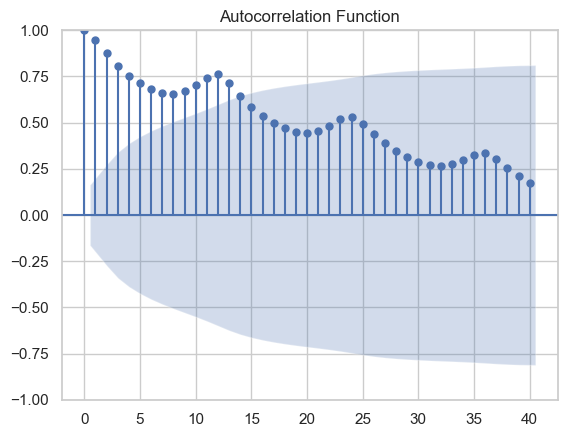

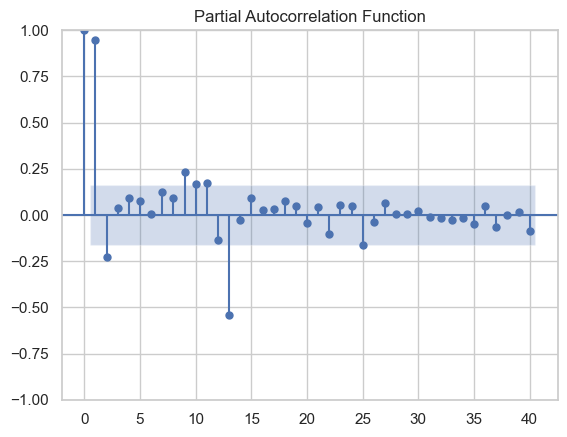

In [72]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Autocorrelation (ACF) Plot
plot_acf(time_series, lags=40)
plt.title('Autocorrelation Function')
plt.show()

# Partial Autocorrelation (PACF) Plot
plot_pacf(time_series, lags=40, method='ywm')
plt.title('Partial Autocorrelation Function')
plt.show()


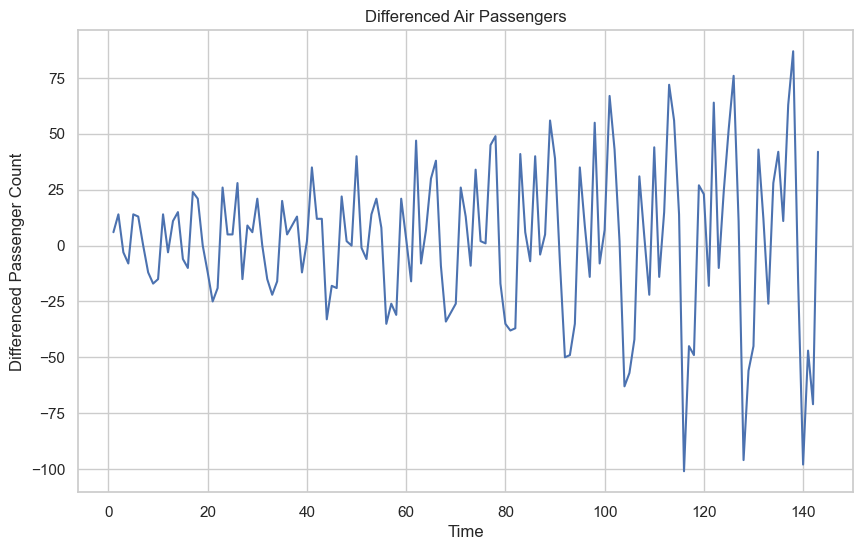

In [73]:
# Differencing to remove trend and seasonality
ap_diff = ap['#Passengers'].diff().dropna()

# Plotting the differenced series
plt.figure(figsize=(10, 6))
plt.plot(ap_diff)
plt.title('Differenced Air Passengers')
plt.xlabel('Time')
plt.ylabel('Differenced Passenger Count')
plt.show()


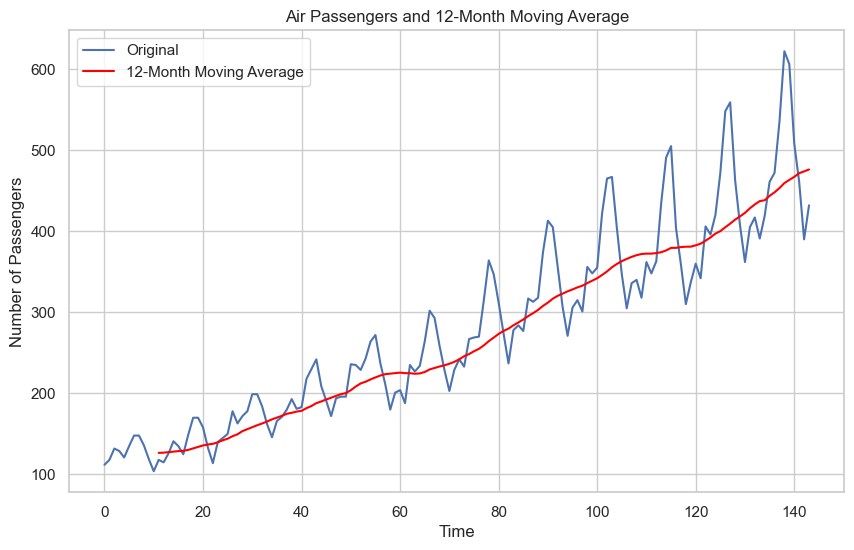

In [74]:
# Calculating the 12-month moving average
ap_ma = ap['#Passengers'].rolling(window=12).mean()

# Plotting the original and moving average series
plt.figure(figsize=(10, 6))
plt.plot(ap['#Passengers'], label='Original')
plt.plot(ap_ma, label='12-Month Moving Average', color='red')
plt.title('Air Passengers and 12-Month Moving Average')
plt.xlabel('Time')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()


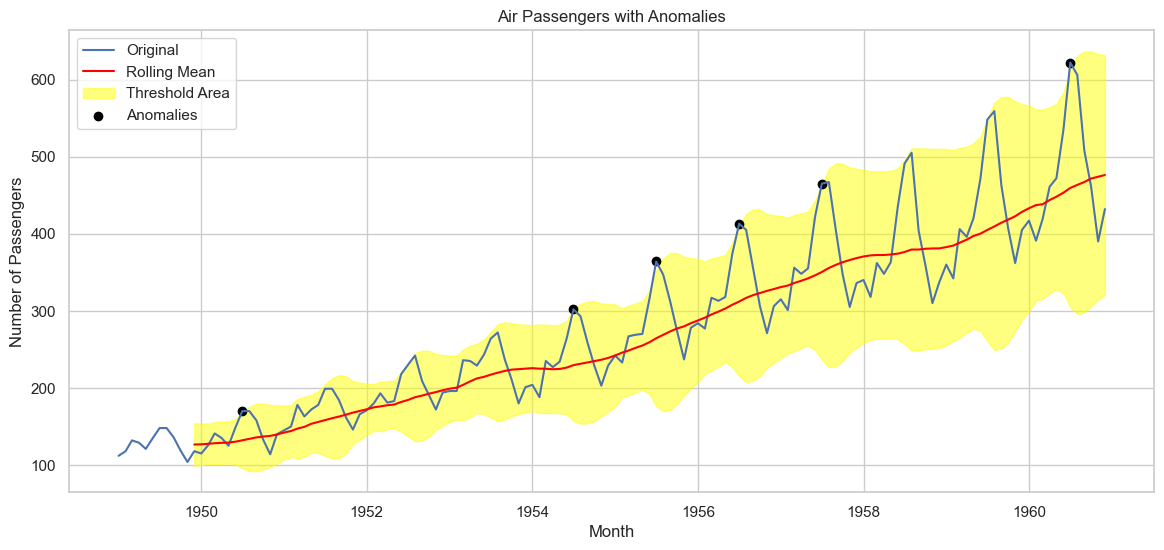

In [75]:
# Calculate rolling mean and standard deviation
window_size = 12  # Example: 12 months for yearly seasonality
rolling_mean = ap['#Passengers'].rolling(window=window_size).mean()
rolling_std = ap['#Passengers'].rolling(window=window_size).std()

# Define anomaly thresholds
threshold_std = 2  # How many standard deviations to consider as anomaly
upper_threshold = rolling_mean + (rolling_std * threshold_std)
lower_threshold = rolling_mean - (rolling_std * threshold_std)

# Identify anomalies
anomalies = ap[(ap['#Passengers'] > upper_threshold) | (ap['#Passengers'] < lower_threshold)]

# Visualize
plt.figure(figsize=(14, 6))
plt.plot(ap['Month'], ap['#Passengers'], label='Original')
plt.plot(ap['Month'], rolling_mean, color='red', label='Rolling Mean')
plt.fill_between(ap['Month'], upper_threshold, lower_threshold, color='yellow', alpha=0.5, label='Threshold Area')
plt.scatter(anomalies['Month'], anomalies['#Passengers'], color='black', label='Anomalies')
plt.title('Air Passengers with Anomalies')
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()
